# NBA Fantasy Points Predictor

Predict a player's DraftKings fantasy points for a game using only
stats from their previous 10 games (and their team's/opponent's previous 10 games).

**Target:** `FANTASY_PTS = PTSx1 + REBx1.25 + ASTx1.5 + STLx2 + BLKx2 - TOVx0.5 + FG3Mx0.5`

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error

from pathlib import Path

DATA_DIR = Path("data")

## Data Loading

In [2]:
player_logs = pd.read_csv(DATA_DIR / "nba_player_game_logs.csv")
games       = pd.read_csv(DATA_DIR / "nba_historical_games.csv")

# Parse dates
player_logs["GAME_DATE"] = pd.to_datetime(player_logs["GAME_DATE"])
games["date"]            = pd.to_datetime(games["date"])

# Normalize GAME_ID to int for joining (player logs have leading zeros: '0029900001')
player_logs["game_id_int"] = player_logs["GAME_ID"].astype(int)
games["game_id_int"]       = games["game_id"].astype(int)

# Convert MIN to numeric (NBA API occasionally returns "30:45" string format)
player_logs["MIN"] = pd.to_numeric(player_logs["MIN"], errors="coerce")

print("Player logs:", player_logs.shape)
print("Games:      ", games.shape)
player_logs.head(3)

Player logs: (671862, 25)
Games:       (32357, 47)


,SEASON_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MIN,PTS,REB,...,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,PLUS_MINUS,game_id_int
0,21999,431,Shawn Kemp,1610612739,CLE,29900001,1999-11-02,31,17,5,...,20,0.300,0,0,NaN,5,8,0.625,2,29900001
1,21999,95,Mark Bryant,1610612739,CLE,29900001,1999-11-02,15,3,3,...,3,0.333,0,0,NaN,1,2,0.500,-24,29900001
2,21999,1538,Cedric Henderson,1610612739,CLE,29900001,1999-11-02,20,0,2,...,1,0.000,0,0,NaN,0,0,NaN,-17,29900001


In [3]:
print(player_logs.dtypes[["GAME_DATE", "game_id_int", "MIN", "PTS", "REB", "AST"]])
print(games.dtypes[["date", "game_id_int", "home_team", "away_team"]])

GAME_DATE      datetime64[ns]
game_id_int             int32
MIN                     int64
PTS                     int64
REB                     int64
AST                     int64
dtype: object
date           datetime64[ns]
game_id_int             int32
home_team              object
away_team              object
dtype: object


## Target Engineering

DraftKings scoring formula:
- PTS x 1.0
- REB x 1.25
- AST x 1.5
- STL x 2.0
- BLK x 2.0
- TOV x -0.5
- FG3M x 0.5 (3PT bonus)

In [4]:
player_logs["FANTASY_PTS"] = (
    player_logs["PTS"]  * 1.00 +
    player_logs["REB"]  * 1.25 +
    player_logs["AST"]  * 1.50 +
    player_logs["STL"]  * 2.00 +
    player_logs["BLK"]  * 2.00 +
    player_logs["TOV"]  * -0.50 +
    player_logs["FG3M"] * 0.50
)

print(f"Fantasy points - mean: {player_logs['FANTASY_PTS'].mean():.2f}, "
      f"std: {player_logs['FANTASY_PTS'].std():.2f}, "
      f"min: {player_logs['FANTASY_PTS'].min():.2f}, "
      f"max: {player_logs['FANTASY_PTS'].max():.2f}")

Fantasy points â€” mean: 20.54, std: 14.15, min: -2.00, max: 107.75


## Feature Engineering

### Player Features (lag 1-10)

For each player-game, we look back at that player's previous 10 games and use
each game's raw stats as a feature. This gives 8 stats x 10 lags = 80 features.

In [5]:
PLAYER_STATS = ["PTS", "REB", "AST", "STL", "BLK", "TOV", "FG3M", "MIN"]

# Must sort by (player, date) so shift() looks back in time correctly
player_logs = player_logs.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

player_lag_cols = []
for stat in PLAYER_STATS:
    for lag in range(1, 11):
        col = f"player_{stat}_lag{lag}"
        player_logs[col] = player_logs.groupby("PLAYER_ID")[stat].shift(lag)
        player_lag_cols.append(col)

print(f"Player lag features created: {len(player_lag_cols)}")
player_logs[["PLAYER_NAME", "GAME_DATE"] + player_lag_cols[:4]].head()

Player lag features created: 80


,PLAYER_NAME,GAME_DATE,player_PTS_lag1,player_PTS_lag2,player_PTS_lag3,player_PTS_lag4
0,Grant Long,1999-12-27,NaN,NaN,NaN,NaN
1,Grant Long,1999-12-29,4.0,NaN,NaN,NaN
2,Grant Long,1999-12-30,4.0,4.0,NaN,NaN
3,Grant Long,2000-01-04,4.0,4.0,4.0,NaN
4,Grant Long,2000-01-05,1.0,4.0,4.0,4.0


In [6]:
# Spot check: LeBron James lag1 PTS should equal his previous game's PTS
lebron = player_logs[player_logs["PLAYER_NAME"] == "LeBron James"].head(15)
print(lebron[["GAME_DATE", "PTS", "player_PTS_lag1", "player_PTS_lag2"]].to_string())

        GAME_DATE  PTS  player_PTS_lag1  player_PTS_lag2
221640 2003-10-29   25              NaN              NaN
221641 2003-10-30   21             25.0              NaN
221642 2003-11-01    8             21.0             25.0
221643 2003-11-05    7              8.0             21.0
221644 2003-11-07   23              7.0              8.0
221645 2003-11-08   17             23.0              7.0
221646 2003-11-10   17             17.0             23.0
221647 2003-11-12   18             17.0             17.0
221648 2003-11-14   10             18.0             17.0
221649 2003-11-15   22             10.0             18.0
221650 2003-11-18   14             22.0             10.0
221651 2003-11-19   28             14.0             22.0
221652 2003-11-21   19             28.0             14.0
221653 2003-11-22   15             19.0             28.0
221654 2003-11-26   15             15.0             19.0


### Team Features (lag 1-10)

Pivot the games table from wide format (home_/away_ columns) to long format
(one row per team per game). Then compute the same lag-1 through lag-10 features
for each team. This gives 8 stats x 10 lags = 80 team features.

In [7]:
TEAM_STATS = ["score", "fg_made", "fg3_made", "reb", "ast", "stl", "blk", "tov"]

home_games = games[["game_id_int", "date", "home_team",
                     "home_score", "home_fg_made", "home_fg3_made",
                     "home_reb", "home_ast", "home_stl",
                     "home_blk", "home_tov"]].copy()
home_games.columns = ["game_id_int", "date", "team"] + TEAM_STATS

away_games = games[["game_id_int", "date", "away_team",
                     "away_score", "away_fg_made", "away_fg3_made",
                     "away_reb", "away_ast", "away_stl",
                     "away_blk", "away_tov"]].copy()
away_games.columns = ["game_id_int", "date", "team"] + TEAM_STATS

team_games = pd.concat([home_games, away_games], ignore_index=True)
team_games = team_games.sort_values(["team", "date"]).reset_index(drop=True)

print(f"Team-game rows (should be 2 x {len(games):,}): {len(team_games):,}")
team_games.head(3)

Team-game rows (should be 2 Ã— 32,357): 64,714


,game_id_int,date,team,score,fg_made,fg3_made,reb,ast,stl,blk,tov
0,29900003,1999-11-02,ATL,87,31,2,50,15,5,5,23
1,29900021,1999-11-04,ATL,109,41,6,46,22,3,5,26
2,29900037,1999-11-06,ATL,113,44,3,42,21,10,3,12


In [8]:
team_lag_cols = []
for stat in TEAM_STATS:
    for lag in range(1, 11):
        col = f"team_{stat}_lag{lag}"
        team_games[col] = team_games.groupby("team")[stat].shift(lag)
        team_lag_cols.append(col)

print(f"Team lag features created: {len(team_lag_cols)}")

Team lag features created: 80


### Opponent Features (lag 1-10)

For each team-game row, identify the opponent and look up their lag features.
This gives another 80 features (8 stats x 10 lags) representing how the
opposing team has been playing recently.

In [9]:
# Build (game_id_int, team) -> opponent mapping
opp_map = pd.concat([
    games[["game_id_int", "home_team", "away_team"]].rename(
        columns={"home_team": "team", "away_team": "opponent"}),
    games[["game_id_int", "away_team", "home_team"]].rename(
        columns={"away_team": "team", "home_team": "opponent"})
], ignore_index=True)

team_games = team_games.merge(opp_map, on=["game_id_int", "team"], how="left")
print(team_games[["team", "opponent", "date"]].head(3))

  team opponent       date
0  ATL      WAS 1999-11-02
1  ATL      MIL 1999-11-04
2  ATL      CHI 1999-11-06


In [10]:
# Opponent lag features: look up the opponent's own team lag features for this game
opp_lag_cols = [f"opp_{s}_lag{l}" for s in TEAM_STATS for l in range(1, 11)]

opp_lookup = team_games[["game_id_int", "team"] + team_lag_cols].rename(
    columns={"team": "opponent"}
)
opp_lookup.columns = ["game_id_int", "opponent"] + opp_lag_cols

team_games = team_games.merge(opp_lookup, on=["game_id_int", "opponent"], how="left")
print(f"Opponent lag features added: {len(opp_lag_cols)}")

Opponent lag features added: 80


### Feature Matrix Assembly

Join player lag features with team/opponent lag features on (game_id, team).
Drop any row where the player or either team has fewer than 10 prior games
(these produce NaN lags and cannot be used for training).

In [11]:
# Columns needed from team_games
team_cols = ["game_id_int", "team"] + team_lag_cols + opp_lag_cols

df = player_logs.merge(
    team_games[team_cols],
    left_on=["game_id_int", "TEAM_ABBREVIATION"],
    right_on=["game_id_int", "team"],
    how="inner"
)

all_feature_cols = player_lag_cols + team_lag_cols + opp_lag_cols

before = len(df)
df_clean = df.dropna(subset=all_feature_cols).reset_index(drop=True)

print(f"Rows before dropping NaN: {before:,}")
print(f"Rows after  dropping NaN: {len(df_clean):,}")
print(f"Rows dropped (< 10 prior games): {before - len(df_clean):,}")
print(f"Feature matrix: {len(df_clean):,} rows x {len(all_feature_cols)} features")

X = df_clean[all_feature_cols]
y = df_clean["FANTASY_PTS"]

Rows before dropping NaN: 671,862
Rows after  dropping NaN: 645,774
Rows dropped (< 10 prior games): 26,088
Feature matrix: 645,774 rows Ã— 240 features


## Descriptive Analytics

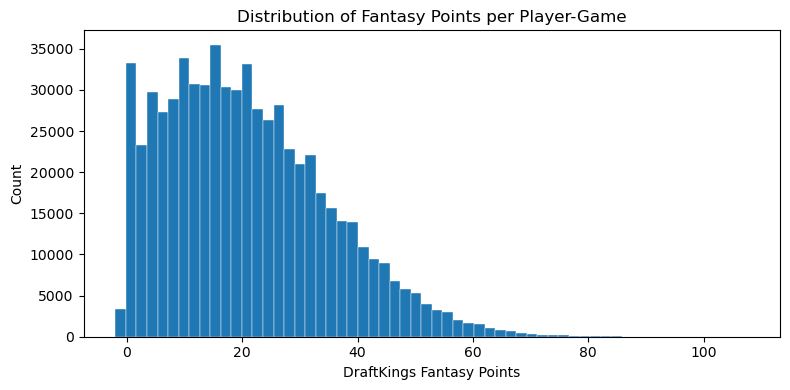

Mean:   20.92
Median: 19.00
Std:    14.13


In [12]:
plt.figure(figsize=(8, 4))
plt.hist(y, bins=60, edgecolor="white", linewidth=0.3)
plt.xlabel("DraftKings Fantasy Points")
plt.ylabel("Count")
plt.title("Distribution of Fantasy Points per Player-Game")
plt.tight_layout()
plt.show()

print(f"Mean:   {y.mean():.2f}")
print(f"Median: {y.median():.2f}")
print(f"Std:    {y.std():.2f}")

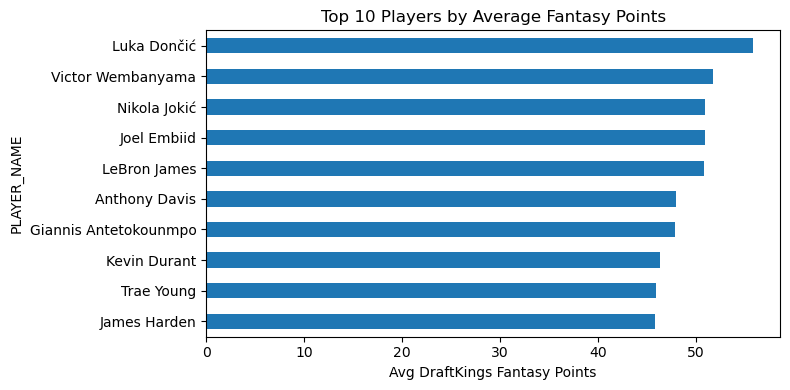

In [13]:
top_players = (
    df_clean.groupby("PLAYER_NAME")["FANTASY_PTS"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
top_players.sort_values().plot(kind="barh")
plt.xlabel("Avg DraftKings Fantasy Points")
plt.title("Top 10 Players by Average Fantasy Points")
plt.tight_layout()
plt.show()

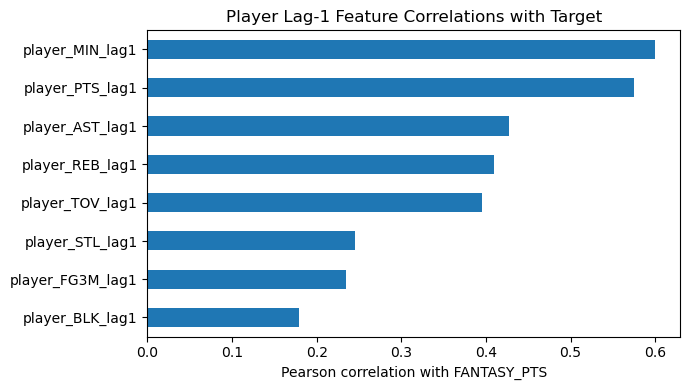

In [14]:
# Lag-1 player stats correlated with target
lag1_cols = [f"player_{s}_lag1" for s in PLAYER_STATS]
correlations = (
    df_clean[lag1_cols + ["FANTASY_PTS"]]
    .corr()["FANTASY_PTS"]
    .drop("FANTASY_PTS")
    .sort_values()
)

plt.figure(figsize=(7, 4))
correlations.plot(kind="barh")
plt.xlabel("Pearson correlation with FANTASY_PTS")
plt.title("Player Lag-1 Feature Correlations with Target")
plt.tight_layout()
plt.show()

## Train/Test Split

We use a **temporal split** to avoid data leakage: train on all games before
the 2023-24 season, test on games from 2023-24 onward.
This is more realistic than a random split - we predict future games from past data.

In [15]:
train_mask = df_clean["GAME_DATE"] < "2023-10-01"

X_train = X[train_mask]
X_test  = X[~train_mask]
y_train = y[train_mask]
y_test  = y[~train_mask]

print(f"Train: {len(X_train):,} rows  ({train_mask.sum() / len(df_clean) * 100:.1f}%)")
print(f"Test:  {len(X_test):,} rows  ({(~train_mask).sum() / len(df_clean) * 100:.1f}%)")
print(f"Train date range: {df_clean.loc[train_mask, 'GAME_DATE'].min().date()} "
      f"-> {df_clean.loc[train_mask, 'GAME_DATE'].max().date()}")
print(f"Test  date range: {df_clean.loc[~train_mask, 'GAME_DATE'].min().date()} "
      f"-> {df_clean.loc[~train_mask, 'GAME_DATE'].max().date()}")

Train: 571,069 rows  (88.4%)
Test:  74,705 rows  (11.6%)
Train date range: 1999-11-20 → 2023-04-09
Test  date range: 2023-10-24 → 2026-04-01


## Baseline Model: Linear Regression

We follow the standard sklearn workflow from class:
1. Choose model class
2. Instantiate with hyperparameters
3. Fit to training data
4. Predict and evaluate

`StandardScaler` is included because our 240 features have very different scales
(e.g., MIN in [0,48] vs FG3M in [0,10]). Ridge/Lasso will be explored next.

In [16]:
# 1. choose model class
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 2. instantiate model
model = make_pipeline(StandardScaler(), LinearRegression())

# 3. fit model to data
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [17]:
# 4. predict on training/testing data, evaluate
from sklearn.metrics import mean_squared_error
import numpy as np

train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
test_rmse  = np.sqrt(mean_squared_error(y_test,  model.predict(X_test)))

print(f"Train RMSE: {train_rmse:.3f} fantasy points")
print(f"Test  RMSE: {test_rmse:.3f} fantasy points")

Train RMSE: 9.365 fantasy points
Test  RMSE: 9.811 fantasy points


In [ ]:
from sklearn.model_selection import cross_val_score

cv_rmses = np.sqrt(
    -cross_val_score(model, X_train, y_train, cv=5,
                     scoring="neg_mean_squared_error")
)

print(f"CV RMSE (5-fold): {cv_rmses.mean():.3f} +/- {cv_rmses.std():.3f}")
print(f"Per-fold:         {np.round(cv_rmses, 3)}")

In [ ]:
print("=" * 45)
print("   Linear Regression - Results Summary")
print("=" * 45)
print(f"   Train RMSE : {train_rmse:.3f} fantasy pts")
print(f"   Test  RMSE : {test_rmse:.3f} fantasy pts")
print(f"   CV    RMSE : {cv_rmses.mean():.3f} +/- {cv_rmses.std():.3f}")
print("=" * 45)
print(f"Baseline: always predict mean -> RMSE = {y_test.std():.3f}")
print(f"   Improvement over baseline: "
      f"{(1 - test_rmse / y_test.std()) * 100:.1f}%")